Heaps, Priority Queues, Heapq

(from Greg Hogg
https://www.youtube.com/watch?v=E2v9hBgG6gE)

In [ ]:
pip install matplotlib networkx


In [5]:
'''
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# Function to visualize the heap as a binary tree
def visualize_heap(heap):
    # Create a directed graph
    G = nx.DiGraph()

    # Add nodes and edges to the graph
    for i in range(len(heap)):
        G.add_node(i, label=heap[i])
        if 2*i + 1 < len(heap):
            G.add_edge(i, 2*i + 1)
        if 2*i + 2 < len(heap):
            G.add_edge(i, 2*i + 2)

    # Define the layout for the graph
    pos = nx.spring_layout(G, k=5)

    # Draw the graph
    nx.draw(G, pos, with_labels=True, labels=nx.get_node_attributes(G, 'label'),
            node_size=200, node_color='lightblue', font_size=10, font_color='black')
    plt.show()
'''

In [25]:
import matplotlib.pyplot as plt
import networkx as nx
import math

def draw_interactive_heap_tree(heap):
    """Draw an interactive binary heap tree using matplotlib and networkx."""
    def add_edges(G, heap, index=0):
        """Recursively add edges to the graph."""
        left = 2 * index + 1
        right = 2 * index + 2
        if left < len(heap):
            G.add_edge(heap[index], heap[left])
            add_edges(G, heap, left)
        if right < len(heap):
            G.add_edge(heap[index], heap[right])
            add_edges(G, heap, right)

    # Create a directed graph
    G = nx.DiGraph()
    add_edges(G, heap)

    # Custom layout for nodes based on their level and index in the heap
    pos = {}
    horizontal_spacing = 0.1 # Increase for wider spacing
    vertical_spacing = 0.1 # Increase for taller spacing

    for i, node in enumerate(heap):
        level = int(math.log2(i + 1))
        index_in_level = i - (2 ** level - 1)
        pos[node] = (index_in_level * horizontal_spacing, (-level) * vertical_spacing)

    # Draw the graph
    fig, ax = plt.subplots(figsize=(10, 6))
    nx.draw(G, pos, with_labels=True, node_size=500, node_color="skyblue",
            font_size=10, font_color="black", arrows=False, ax=ax)

    # Add interactivity: zooming and panning
    def on_scroll(event):
        scale_factor = 1.1 if event.button == 'up' else 0.9
        ax.set_xlim([scale_factor * x for x in ax.get_xlim()])
        ax.set_ylim([scale_factor * y for y in ax.get_ylim()])
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect('scroll_event', on_scroll)

    # Add interactivity: hover tooltips
    tooltip = ax.annotate("", xy=(0,0), xytext=(20,20),
                          textcoords="offset points",
                          bbox=dict(boxstyle="round", fc="w"),
                          arrowprops=dict(arrowstyle="->"))
    tooltip.set_visible(False)

    def on_hover(event):
        if event.inaxes == ax:
            for node, (x, y) in pos.items():
                if abs(event.xdata - x) < 0.1 and abs(event.ydata - y) < 0.1:
                    tooltip.xy = (x, y)
                    tooltip.set_text(str(node))
                    tooltip.set_visible(True)
                    fig.canvas.draw_idle()
                    return
            tooltip.set_visible(False)
            fig.canvas.draw_idle()

    fig.canvas.mpl_connect('motion_notify_event', on_hover)

    plt.title("Interactive Binary Heap Tree")
    plt.show()

In [26]:

# Create a heap
heap = []
heapq.heappush(heap, 10)
heapq.heappush(heap, 20)
heapq.heappush(heap, 5)
heapq.heappush(heap, 15)
heapq.heappush(heap, 30)
heap

[5, 15, 10, 20, 30]

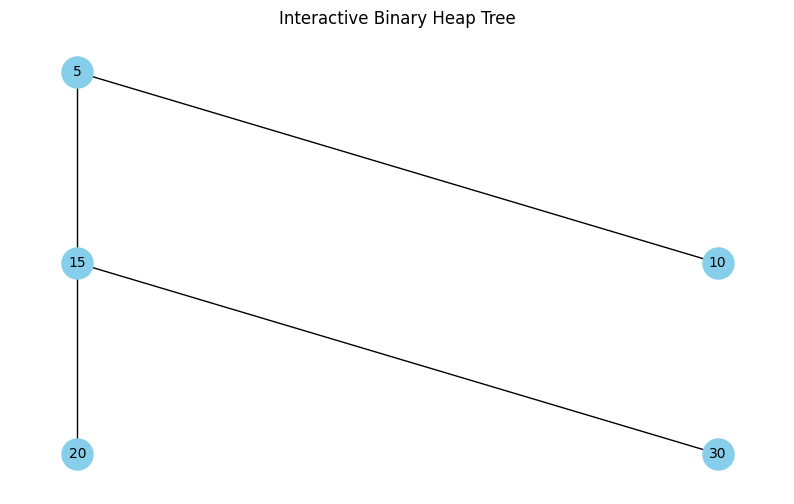

In [27]:
# Visualize the heap
#visualize_heap(heap)
draw_interactive_heap_tree(heap)

In [34]:
# Build Min Heap (Heapify)
# Time: O(n), Space: O(1)

A = [-4, 3, 1, 0, 2, 5, 10, 8, 12, 9]

import heapq

heapq.heapify(A)
A # Not sorted but min-heapified


[-4, 0, 1, 3, 2, 5, 10, 8, 12, 9]

In [35]:
#draw_interactive_heap_tree(A)

In [36]:
# Heap Push (Insert element)
# Time: O(log n)

heapq.heappush(A, 4)
A

[-4, 0, 1, 3, 2, 5, 10, 8, 12, 9, 4]

In [37]:
# visualize
#draw_interactive_heap_tree(A)

In [38]:
# Heap Pop Extract the lowest)
# Time: O(log n)

smallest = heapq.heappop(A)
A, smallest

([0, 2, 1, 3, 4, 5, 10, 8, 12, 9], -4)

In [39]:
# Heap Sort
# Time: O(n log n), Space: O(n)
# Note: O(1) Space is possible via swapping, but this is complex

def heapsort(arr):
  heapq.heapify(arr)
  n = len(arr)
  new_list = [0] * n

  for i in range(n):
    minn = heapq.heappop(arr)
    new_list[i] = minn

  return new_list

heapsort([1, 3, 5, 7, 9, 2, 4, 6, 8, 0])


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
# Heap Push Pop
# Time: O(log n)

heapq.heappushpop(A, 99)
A

[1, 2, 5, 3, 4, 99, 10, 8, 12, 9]

In [42]:
# Peak at Min: Time O(1)
A[0]

0

In [43]:
# Max Heap

B = [-4, 3, 1, 0, 2, 5, 10, 8, 12, 9]
n = len(B)

for i in range(n):
  B[i] *= -1

heapq.heapify(B)
B

[-12, -9, -10, -8, -2, -5, -1, -3, 0, 4]

In [44]:
largestb = -heapq.heappop(B)
largestb

12

In [45]:
heapq.heappush(B, -7) # Insert 7
B

[-10, -9, -5, -8, -7, 4, -1, -3, 0, -2]

In [46]:
# Build heap from scratch

C = [-5, 4, 2, 1, 7, 0, 3]

heap = []

for i in C:
  heapq.heappush(heap, i)
  print(heap, len(heap))



[-5] 1
[-5, 4] 2
[-5, 4, 2] 3
[-5, 1, 2, 4] 4
[-5, 1, 2, 4, 7] 5
[-5, 1, 0, 4, 7, 2] 6
[-5, 1, 0, 4, 7, 2, 3] 7


In [47]:
# Putting tuples of items on the heap

D = [5, 4, 3, 5, 4, 3, 5, 5, 4]

from collections import Counter
counter = Counter(D)

counter

Counter({5: 4, 4: 3, 3: 2})

In [ ]:
heap = []
for k, v in counter.items():
  heapq.heappush(heap, (v, k))

heap

[(2, 3), (4, 5), (3, 4)]

In [48]:
# Copilot

def min_heapify(arr, n, i):
    smallest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] < arr[smallest]:
        smallest = left

    if right < n and arr[right] < arr[smallest]:
        smallest = right

    if smallest != i:
        arr[i], arr[smallest] = arr[smallest], arr[i]
        min_heapify(arr, n, smallest)

def build_min_heap(arr):
    n = len(arr)
    # Start from the last non-leaf node and heapify each node
    for i in range(n // 2 - 1, -1, -1):
        min_heapify(arr, n, i)
    return arr


def insert(heap, key):
    heap.append(key)
    i = len(heap) - 1
    # Bubble up
    while i > 0:
        parent = (i - 1) // 2
        if heap[i] < heap[parent]:
            heap[i], heap[parent] = heap[parent], heap[i]
            i = parent
        else:
            break

def delete_min(heap):
    n = len(heap)
    if n == 0:
        return None
    root = heap[0]
    heap[0] = heap[-1]
    heap.pop()
    min_heapify(heap, len(heap), 0)
    return root


heap = [9, 5, 6, 2, 3]
build_min_heap(heap)
print("Initial Min-Heap:", heap)

insert(heap, 1)
print("After Inserting 1:", heap)

min_element = delete_min(heap)
print("Deleted Min Element:", min_element)
print("After Deletion:", heap)

Initial Min-Heap: [2, 3, 6, 5, 9]
After Inserting 1: [1, 3, 2, 5, 9, 6]
Deleted Min Element: 1
After Deletion: [2, 3, 6, 5, 9]


In [49]:
# Eric Lam
# min-heap, max-heap, visualization

import heapq
import math
def print_heap_tree(heap):
    """Pretty print a binary heap as a tree with parent above children and lines connecting them."""
    def tree_lines(heap, index=0, indent="", last='updown'):
        """Recursively yield lines for the tree structure."""
        if index >= len(heap):
            return
        # Identify children indices
        left = 2 * index + 1
        right = 2 * index + 2
        # Characters for drawing branches
        up = '┌'
        down = '└'
        vert = '│'
        horiz = '──'
        # Node label
        node = str(heap[index])
        # Print right child first (so it appears on top in the output)
        if right < len(heap):
            next_indent = indent + ("     " if last == 'up' else "│    ")
            yield from tree_lines(heap, right, next_indent, 'up')
        # Print current node
        if last == 'up':
            start_shape = up + horiz
        elif last == 'down':
            start_shape = down + horiz
        else:
            start_shape = "   "
        yield indent + start_shape + node
        # Print left child
        if left < len(heap):
            next_indent = indent + ("     " if last == 'down' else "│    ")
            yield from tree_lines(heap, left, next_indent, 'down')
    for line in tree_lines(heap):
        print(line)


# Example usage:
heap = []
for value in [7, 3, 5, 1, 8, 2, 6]:
    heapq.heappush(heap, value)
print("Min-heap visualization:")
print_heap_tree(heap)
# For max-heap visualization (negate values)
max_heap = []
for value in [7, 3, 5, 1, 8, 2, 6]:
    heapq.heappush(max_heap, -value)
print("\nMax-heap visualization:")
print_heap_tree([-v for v in max_heap])


Min-heap visualization:
│         ┌──6
│    ┌──2
│    │    └──5
   1
│    │    ┌──8
│    └──3
│         └──7

Max-heap visualization:
│         ┌──5
│    ┌──6
│    │    └──2
   8
│    │    ┌──3
│    └──7
│         └──1


In [51]:
# Class based implementation

class MinHeap:
    def __init__(self):
        self.heap = []

    def _min_heapify(self, i):
        n = len(self.heap)
        smallest = i
        left = 2 * i + 1
        right = 2 * i + 2

        if left < n and self.heap[left] < self.heap[smallest]:
            smallest = left
        if right < n and self.heap[right] < self.heap[smallest]:
            smallest = right

        if smallest != i:
            self.heap[i], self.heap[smallest] = self.heap[smallest], self.heap[i]
            self._min_heapify(smallest)

    def build_heap(self, arr):
        self.heap = arr[:]
        for i in range(len(self.heap) // 2 - 1, -1, -1):
            self._min_heapify(i)

            while i > 0:
              parent = (i - 1) // 2
              if self.heap[i] < self.heap[parent]:
                  self.heap[i], self.heap[parent] = self.heap[parent], self.heap[i]
                  i = parent
              else:
                break

    def insert(self, key):
      self.heap.append(key)
      i = len(self.heap) - 1
      while i > 0:
        parent = (i - 1) // 2
        if self.heap[i] < self.heap[parent]:
          self.heap[i], self.heap[parent] = self.heap[parent], self.heap[i]
          i = parent
        else:
          break


    def delete_min(self):
        if not self.heap:
            return None
        root = self.heap[0]
        last = self.heap.pop()
        if self.heap:
            self.heap[0] = last
            self._min_heapify(0)
        return root

    def get_min(self):
        return self.heap[0] if self.heap else None

    def __str__(self):
        return str(self.heap)



heap = MinHeap()
heap.build_heap([9, 5, 6, 2, 3])
print("Initial Heap:", heap)

heap.insert(1)
print("After Inserting 1:", heap)

min_val = heap.delete_min()
print("Deleted Min:", min_val)
print("After Deletion:", heap)


Initial Heap: [2, 9, 6, 5, 3]
After Inserting 1: [1, 9, 2, 5, 3, 6]
Deleted Min: 1
After Deletion: [2, 9, 6, 5, 3]


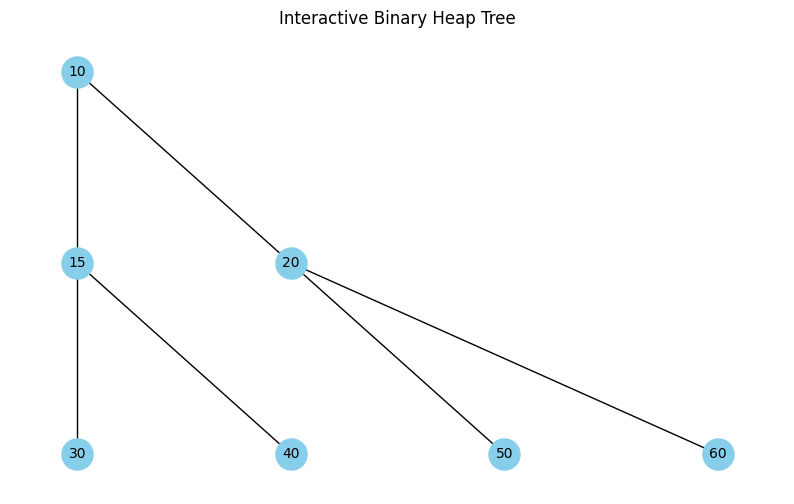

In [52]:
# Example usage
heap = [10, 15, 20, 30, 40, 50, 60]
draw_interactive_heap_tree(heap)